In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Visual

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython import display
import os, re, glob

def create_image_grid(selected_images, grid_cols=5, image_size=(128, 128), spacing=5, group_spacing=20):
    """
    Create a compact grid of images using PIL for bird's eye view.

    Parameters:
        selected_images (list of str): List of selected image names (e.g., "n02106662_6706.jpeg").
        grid_cols (int): Number of columns in the grid (group of GT and generated samples).
        image_size (tuple): Size (width, height) to resize images for the grid.
        spacing (int): Space between images within a group.
        group_spacing (int): Space between groups of images (across different groups).

    Returns:
        PIL Image: The resulting grid image.
    """
    # Total images per group (GT + 2 samples)
    images_per_group = 3
    num_groups = len(selected_images)

    # Calculate grid size
    grid_rows = (num_groups + grid_cols - 1) // grid_cols
    grid_width = grid_cols * images_per_group * image_size[0] + (grid_cols - 1) * spacing + (grid_cols - 1) * group_spacing
    grid_height = grid_rows * (image_size[1] + spacing) + (grid_rows - 1) * group_spacing + 50  # Extra space for labels

    # Create a blank canvas
    grid_image = Image.new("RGB", (grid_width, grid_height), "white")

    # Create a drawing object
    draw = ImageDraw.Draw(grid_image)

    # Font for text
    font = ImageFont.load_default(size=40)

    # Draw dashed vertical lines after every column
    line_color = (64, 64, 64)  # Black color for the lines
    line_width = 5  # Line width
    dash_length = 20  # Length of each dash

    for col in range(1, grid_cols):
        x_pos = col * images_per_group * image_size[0] + col * spacing + col * group_spacing - group_spacing // 2 + 1
        for y in range(0, grid_height, dash_length * 2):  # Drawing the dashes
            draw.line((x_pos, y-70, x_pos, min(y-70 + dash_length, grid_height)), fill=line_color, width=line_width)

    # Load and paste images into the grid
    for i, (image_name, subject_1, sample_1, subject_2, sample_2) in enumerate(selected_images):
        group_col = i % grid_cols  # Column index for this group
        group_row = i // grid_cols  # Row index for this group

        # X and Y offsets for images
        x_offset = group_col * images_per_group * image_size[0] + group_col * spacing + group_col * group_spacing
        y_offset = group_row * (image_size[1] + spacing) + group_row * group_spacing

        # Paths for original and generated images
        gt_path = os.path.join(WORK_DIR, "picture-gene-onlygt", image_name)
        generated_path_1 = glob.glob(f"{WORK_DIR}/picture-gene/{image_name.split('.')[0]}_{subject_1}_*_{sample_1}.png")[0]
        generated_path_2 = glob.glob(f"{WORK_DIR}/picture-gene/{image_name.split('.')[0]}_{subject_2}_*_{sample_2}.png")[0]

        try:
            # Load and resize images
            gt_image = Image.open(gt_path).resize(image_size).convert("RGB")
            gen_image_1 = Image.open(generated_path_1).resize(image_size).convert("RGB")
            gen_image_2 = Image.open(generated_path_2).resize(image_size).convert("RGB")

            # Paste images into grid
            grid_image.paste(gt_image, (x_offset, y_offset))
            grid_image.paste(gen_image_1, (x_offset + image_size[0] + spacing, y_offset))
            grid_image.paste(gen_image_2, (x_offset + 2 * (image_size[0] + spacing), y_offset))

            # Draw a red bounding box around the first image in the group (ground truth)
            draw.rectangle(
                [x_offset, y_offset, x_offset + image_size[0], y_offset + image_size[1]],
                outline="red",
                width=5
            )
        except FileNotFoundError as e:
            print(f"Error: {e} for {image_name}")
            continue

    # Add labels only at the bottom row of the canvas
    text_y_offset = grid_height - 30  # Position for text at the very bottom
    for col in range(grid_cols):
        # X-offset for each group
        x_offset = col * images_per_group * image_size[0] + col * spacing + col * group_spacing

        draw.text((x_offset + image_size[0] // 2, text_y_offset), "GT", fill="black", font=font, anchor="mm")
        draw.text((x_offset + image_size[0] + spacing + image_size[0] // 2, text_y_offset), "Sample 1", fill="black", font=font, anchor="mm")
        draw.text((x_offset + 2 * (image_size[0] + spacing) + image_size[0] // 2, text_y_offset), "Sample 2", fill="black", font=font, anchor="mm")

    return grid_image

In [ ]:
!unzip -nq /content/drive/MyDrive/thesis/full_evaluation_beta_interp/work.zip -d /content/

In [ ]:
WORK_DIR = "/content/work"

selected_images = [

    ('0214_mailbag.jpg', 's1', 0, 's1', 1),
    ('0214_mailbag.jpg', 's1', 2, 's1', 3),
    ('0214_mailbag.jpg', 's2', 0, 's2', 1),
    ('0214_mailbag.jpg', 's2', 2, 's2', 3),
    ('0214_mailbag.jpg', 's3', 0, 's3', 1),
    ('0214_mailbag.jpg', 's3', 2, 's3', 3),
    ('0214_mailbag.jpg', 's4', 0, 's4', 1),
    ('0214_mailbag.jpg', 's4', 2, 's4', 3),
    ('0214_mailbag.jpg', 's5', 0, 's5', 1),
    ('0214_mailbag.jpg', 's5', 2, 's5', 3),
    ('0214_mailbag.jpg', 's6', 0, 's6', 1),
    ('0214_mailbag.jpg', 's6', 2, 's6', 3),

    # ('0901_cat.jpg', 's4', 1, 's2', 1),
    # ('1336_canoe.jpg', 's2', 0, 's2', 3),
    # ('0838_computer.jpg', 's3', 2, 's4', 0),

    # ('0604_parachute.jpg', 's2', 2, 's3', 2),
    # ('0193_pool.jpg', 's2', 3, 's2', 2),
    # ('0040_piano.jpg', 's1', 2, 's4', 0),

    # ('0102_parachute.jpg', 's3', 0, 's3', 1),
    # ('0749_guitar.jpg', 's4', 0, 's4', 3),
    # ('0964_bike.jpg', 's4', 1, 's4', 3),

    # ('0467_broom.jpg', 's1', 2, 's1', 1),
    # ('0435_golf.jpg', 's3', 2, 's2', 1),
    # ('0032_locomotive.jpg', 's2', 3, 's4', 2),

    # ('0801_mug.jpg', 's4', 1, 's4', 0),
    # ('0858_dog.jpg', 's3', 0, 's4', 0),
    # ('0053_chair.jpg', 's2', 1, 's5', 0),

    # ('0745_convertible.jpg', 's1', 1, 's1', 3),
    # ('0219_chair.jpg', 's2', 1, 's4', 1),
    # ('0981_cat.jpg', 's2', 1, 's1', 2),
 ]

create_image_grid(selected_images, grid_cols=3, image_size=(300, 300), spacing=5, group_spacing=30)

In [ ]:
!ls /content/work/work/picture-gene/1433_panda_s3_panda_0.png

/content/work/work/picture-gene/1433_panda_s3_panda_0.png


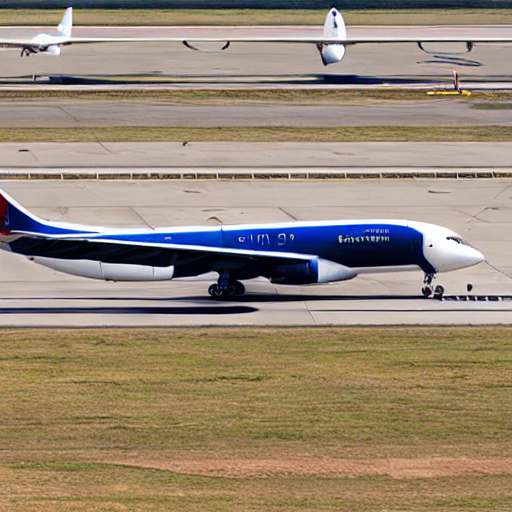

In [ ]:
# Display an image using IPython display module
from IPython.display import display
from PIL import Image

path = "/content/work/work/picture-gene/1989_airliner_s5_airliner_3.png"

image = Image.open(path)
display(image)

In [ ]:

# grid_cols=5
# image_size=(300, 300)
# subject=4
# spacing=5
# group_spacing=0
# # Total images per group (GT + 2 samples)
# images_per_group = 2
# num_groups = len(selected_images)

# # Calculate grid size
# grid_rows = num_groups
# grid_width = (grid_cols * images_per_group * image_size[0] + (grid_cols - 1) * spacing + (grid_cols - 1) * group_spacing) - image_size[0]
# grid_height = grid_rows * (image_size[1] + spacing) + (grid_rows - 1) * group_spacing + 50  # Extra space for labels

# # Create a blank canvas
# grid_image = Image.new("RGB", (grid_width, grid_height), "white")

# # Create a drawing object
# draw = ImageDraw.Draw(grid_image)

# # Font for text
# font = ImageFont.load_default(size=40)

# # Draw dashed vertical lines after every column
# # line_color = (64, 64, 64)  # Black color for the lines
# # line_width = 5  # Line width
# # dash_length = 20  # Length of each dash
# #
# # for col in range(1, grid_cols):
# #     x_pos = col * images_per_group * image_size[0] + col * spacing + col * group_spacing - group_spacing // 2 + 1
# #     for y in range(0, grid_height, dash_length * 2):  # Drawing the dashes
# #         draw.line((x_pos, y-70, x_pos, min(y-70 + dash_length, grid_height)), fill=line_color, width=line_width)

# # Load and paste images into the grid
# for i, image_name in enumerate(selected_images):
#     generated_path = []
#     group_col = 0
#     group_row = i

#     # X and Y offsets for images
#     x_offset = group_col * images_per_group * image_size[0] + group_col * spacing + group_col * group_spacing
#     y_offset = group_row * (image_size[1] + spacing) + group_row * group_spacing

#     # Paths for original and generated images
#     gt_path = os.path.join(WORK_DIR, "00", "picture-gene-onlygt", image_name)
#     for alpha_dir in ["00", "50", "65", "100"]:
#       generated_path.append(glob.glob(f"{WORK_DIR}/{alpha_dir}/picture-gene/{image_name.split('.')[0]}_s{subject}_*_0.png")[0])
#     for alpha_dir in ["00", "50", "65", "100"]:
#       generated_path.append(glob.glob(f"{WORK_DIR}/{alpha_dir}/picture-gene/{image_name.split('.')[0]}_s{subject}_*_1.png")[0])

#     try:
#         # Load and resize images
#         gt_image = Image.open(gt_path).resize(image_size).convert("RGB")
#         grid_image.paste(gt_image, (x_offset, y_offset))
#         # Draw a red bounding box around the first image in the group (ground truth)
#         draw.rectangle(
#             [x_offset, y_offset, x_offset + image_size[0], y_offset + image_size[1]],
#             outline="red",
#             width=5
#         )
#         for j, gen_path in enumerate(generated_path):
#           gen_image = Image.open(gen_path).resize(image_size).convert("RGB")

#           if j == 4:
#             x_offset = x_offset + spacing
#           grid_image.paste(gen_image, (x_offset + (j+1) * image_size[0] + spacing, y_offset))
#     except FileNotFoundError as e:
#         print(f"Error: {e} for {image_name}")
#         continue

# # Add labels only at the bottom row of the canvas
# text_y_offset = grid_height - 30  # Position for text at the very bottom
# draw.text((x_offset + image_size[0] // 2, text_y_offset), "GT", fill="black", font=font, anchor="mm")
# for col in range(2):
#     # X-offset for each group
#     x_offset = col * 4 * image_size[0] + col * spacing + col * group_spacing

#     draw.text((x_offset + image_size[0] + spacing + image_size[0] // 2, text_y_offset), "alpha=0", fill="black", font=font, anchor="mm")
#     draw.text((x_offset + 2 * (image_size[0]) + image_size[0] // 2, text_y_offset), "alpha=0.50", fill="black", font=font, anchor="mm")
#     draw.text((x_offset + 3 * (image_size[0]) + image_size[0] // 2, text_y_offset), "alpha=0.65", fill="black", font=font, anchor="mm")
#     draw.text((x_offset + 4 * (image_size[0]) + image_size[0] // 2, text_y_offset), "alpha=1", fill="black", font=font, anchor="mm")

# grid_image